# ch291 — Feature Engineering

*(Uses correlation from ch280, MI from ch290, normalization from ch273; prepares features for ch292–294)*

## 1. Why Feature Engineering Matters

A model can only discover relationships the input features make expressible. If the true relationship is $y = x^2$ and you provide only $x$, a linear model will fail regardless of how much data you have. Feature engineering is the process of constructing representations that make patterns learnable.

It is not magic. It is applied domain knowledge encoded as mathematical transformations.

---

## 2. Numerical Transformations

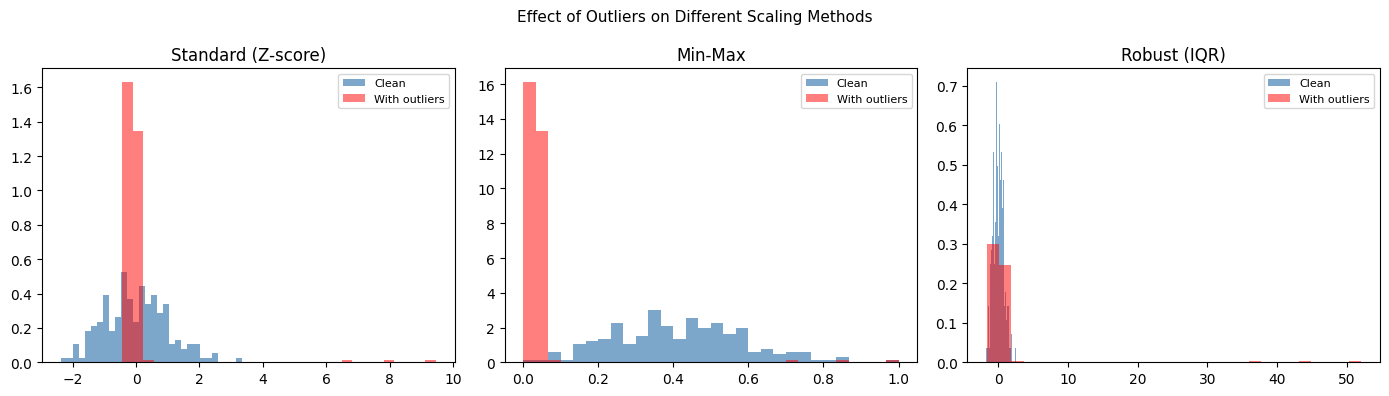

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

# --- Scaling / Normalization ---

def standard_scale(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Z-score normalization. Returns (X_scaled, mean, std)."""
    mu  = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    return (X - mu) / np.where(std == 0, 1, std), mu, std

def min_max_scale(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Min-max normalization to [0, 1]. Returns (X_scaled, min, max)."""
    lo, hi = X.min(axis=0), X.max(axis=0)
    return (X - lo) / np.where(hi == lo, 1, hi - lo), lo, hi

def robust_scale(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Scale using median and IQR — robust to outliers."""
    med = np.median(X, axis=0)
    iqr = np.percentile(X, 75, axis=0) - np.percentile(X, 25, axis=0)
    return (X - med) / np.where(iqr == 0, 1, iqr), med, iqr

# Demonstrate: outlier sensitivity of different scalers
x_clean   = rng.normal(50, 10, 200)
x_dirty   = np.append(x_clean, [500, 600, 700])  # 3 outliers

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
scalers = [
    ('Standard (Z-score)', lambda x: standard_scale(x.reshape(-1,1))[0].ravel()),
    ('Min-Max',            lambda x: min_max_scale(x.reshape(-1,1))[0].ravel()),
    ('Robust (IQR)',       lambda x: robust_scale(x.reshape(-1,1))[0].ravel()),
]

for ax, (name, fn) in zip(axes, scalers):
    sc_clean = fn(x_clean)
    sc_dirty = fn(x_dirty)
    ax.hist(sc_clean, bins=30, color='steelblue', alpha=0.7, density=True, label='Clean')
    ax.hist(sc_dirty, bins=30, color='red',       alpha=0.5, density=True, label='With outliers')
    ax.set_title(name); ax.legend(fontsize=8)

plt.suptitle('Effect of Outliers on Different Scaling Methods', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Distribution Transformations

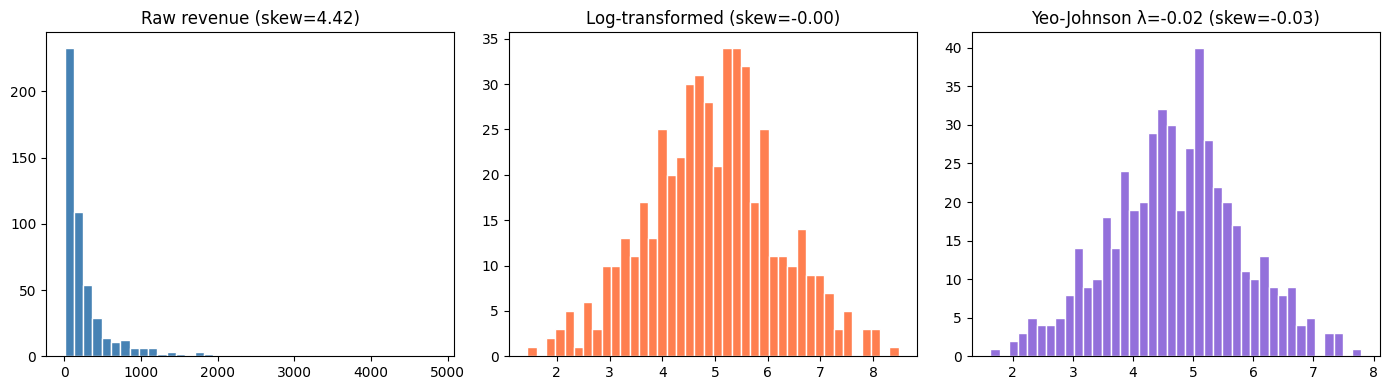

In [2]:
# Log transform: linearizes exponential relationships, compresses right skew
revenue = rng.lognormal(mean=5, sigma=1.2, size=500)

def yeo_johnson_transform(x: np.ndarray, lam: float) -> np.ndarray:
    """
    Yeo-Johnson transform (handles negative values, unlike Box-Cox).
    lam=1 is identity; lam=0 is log-transform for positive x.
    """
    result = np.zeros_like(x, dtype=float)
    pos    = x >= 0
    neg    = ~pos

    if lam != 0:
        result[pos] = ((x[pos] + 1)**lam - 1) / lam
    else:
        result[pos] = np.log(x[pos] + 1)

    if lam != 2:
        result[neg] = -((-x[neg] + 1)**(2 - lam) - 1) / (2 - lam)
    else:
        result[neg] = -np.log(-x[neg] + 1)

    return result

# Find best lambda via maximum likelihood (simple grid search)
def best_yeo_johnson_lambda(x: np.ndarray) -> float:
    lambdas   = np.linspace(-2, 2, 100)
    log_likes = []
    for lam in lambdas:
        x_t    = yeo_johnson_transform(x, lam)
        log_like = -0.5 * len(x) * np.log(np.var(x_t)) + (lam - 1) * np.sum(np.sign(x) * np.log(np.abs(x) + 1))
        log_likes.append(log_like)
    return lambdas[np.argmax(log_likes)]

lam_best = best_yeo_johnson_lambda(revenue)
rev_transformed = yeo_johnson_transform(revenue, lam_best)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(revenue, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Raw revenue (skew={stats.skew(revenue):.2f})')

axes[1].hist(np.log(revenue), bins=40, color='coral', edgecolor='white')
axes[1].set_title(f'Log-transformed (skew={stats.skew(np.log(revenue)):.2f})')

axes[2].hist(rev_transformed, bins=40, color='mediumpurple', edgecolor='white')
axes[2].set_title(f'Yeo-Johnson λ={lam_best:.2f} (skew={stats.skew(rev_transformed):.2f})')

plt.tight_layout()
plt.show()

## 4. Encoding Categorical Variables

In [3]:
def one_hot_encode(x: np.ndarray) -> tuple[np.ndarray, list]:
    """One-hot encoding. Returns (matrix, category_names)."""
    cats    = sorted(np.unique(x))
    n, k    = len(x), len(cats)
    result  = np.zeros((n, k), dtype=int)
    cat_idx = {c: i for i, c in enumerate(cats)}
    for i, val in enumerate(x):
        result[i, cat_idx[val]] = 1
    return result, cats

def target_encode(
    x: np.ndarray,
    y: np.ndarray,
    smoothing: float = 10.0,
) -> tuple[np.ndarray, dict]:
    """
    Target encoding: replace category with smoothed mean of target.
    Smoothing prevents overfitting on rare categories.
    """
    global_mean = y.mean()
    cats  = np.unique(x)
    enc   = {}
    for c in cats:
        mask  = x == c
        n_c   = mask.sum()
        mu_c  = y[mask].mean()
        # Smoothed estimate: weight toward global mean for small groups
        enc[c] = (n_c * mu_c + smoothing * global_mean) / (n_c + smoothing)
    result = np.array([enc[v] for v in x])
    return result, enc

n = 300
country = rng.choice(['US', 'UK', 'DE', 'FR', 'ES'], n, p=[0.4,0.2,0.2,0.1,0.1])
revenue = {'US': 100, 'UK': 90, 'DE': 85, 'FR': 80, 'ES': 70}
y_target = np.array([revenue[c] for c in country]) + rng.normal(0, 15, n)

ohe, cats = one_hot_encode(country)
te,  enc  = target_encode(country, y_target)

print("One-hot encoding shape:", ohe.shape)
print("One-hot categories:", cats)
print()
print("Target encoding (smoothed mean revenue):")
for c, v in sorted(enc.items()):
    print(f"  {c}: {v:.2f}  (true: {revenue[c]})")

One-hot encoding shape: (300, 5)
One-hot categories: [np.str_('DE'), np.str_('ES'), np.str_('FR'), np.str_('UK'), np.str_('US')]

Target encoding (smoothed mean revenue):
  DE: 85.35  (true: 85)
  ES: 76.69  (true: 70)
  FR: 80.09  (true: 80)
  UK: 90.37  (true: 90)
  US: 99.72  (true: 100)


## 5. Feature Selection via MI

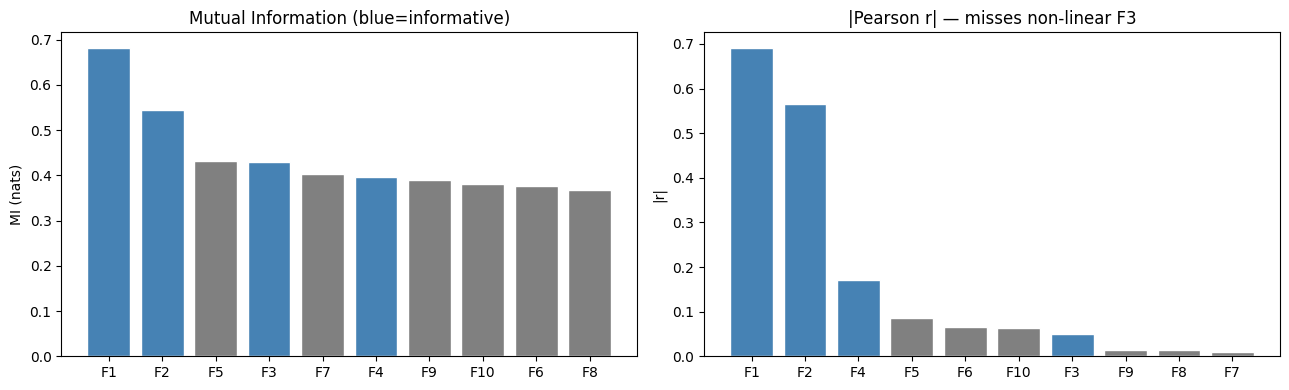

F3 (x²) has high MI but low |r| — Pearson misses the quadratic relationship.


In [4]:
def discretize(arr, bins=20):
    return np.digitize(arr, np.percentile(arr, np.linspace(0, 100, bins)))

def mutual_information_discrete(x, y):
    x_vals = np.unique(x); y_vals = np.unique(y)
    n = len(x)
    joint = np.zeros((len(x_vals), len(y_vals)))
    xi = {v:i for i,v in enumerate(x_vals)}
    yi = {v:i for i,v in enumerate(y_vals)}
    for xv, yv in zip(x, y):
        joint[xi[xv], yi[yv]] += 1
    joint /= n
    px = joint.sum(axis=1); py = joint.sum(axis=0)
    def h(p): p = p[p>0]; return -np.sum(p*np.log(p))
    return h(px) + h(py) - h(joint.flatten())

# Build a dataset with 10 features, only 4 informative
n = 500
f1 = rng.normal(0, 1, n)
f2 = rng.normal(0, 1, n)
f3 = rng.normal(0, 1, n)
f4 = rng.normal(0, 1, n)
noise = [rng.normal(0, 1, n) for _ in range(6)]

y = 2*f1 - 1.5*f2 + f3**2 + 0.5*f4 + rng.normal(0, 0.5, n)
X = np.column_stack([f1, f2, f3, f4] + noise)
feature_names = [f'F{i+1}' for i in range(10)]

y_disc = discretize(y)
mi_scores = [
    mutual_information_discrete(discretize(X[:, i]), y_disc)
    for i in range(X.shape[1])
]
pearson_r = [
    abs(np.corrcoef(X[:, i], y)[0, 1])
    for i in range(X.shape[1])
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
idx = np.argsort(mi_scores)[::-1]

colors = ['steelblue' if i < 4 else 'gray' for i in range(10)]

axes[0].bar([feature_names[i] for i in idx], [mi_scores[i] for i in idx],
            color=[colors[i] for i in idx], edgecolor='white')
axes[0].set_title('Mutual Information (blue=informative)')
axes[0].set_ylabel('MI (nats)')

idx_r = np.argsort(pearson_r)[::-1]
axes[1].bar([feature_names[i] for i in idx_r], [pearson_r[i] for i in idx_r],
            color=[colors[i] for i in idx_r], edgecolor='white')
axes[1].set_title('|Pearson r| — misses non-linear F3')
axes[1].set_ylabel('|r|')

plt.tight_layout()
plt.show()

print("F3 (x²) has high MI but low |r| — Pearson misses the quadratic relationship.")

## 6. What Comes Next

Feature engineering creates representations. **ch292 — Dimensionality Reduction** reduces the number of features while preserving the most information — a mathematical operation on the feature space using tools from Part VI (PCA via SVD). The clean, engineered features produced here are the direct input to that chapter.